In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
x= df.drop("target", axis=1)
y = df['target']

In [5]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)
clf.get_params()
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [6]:
clf.score(x_test,y_test)

0.8360655737704918

In [7]:
from sklearn.model_selection import cross_val_score
cross_val_score(clf,x,y,cv=5)

array([0.83606557, 0.90163934, 0.78688525, 0.81666667, 0.76666667])

In [8]:
print(f"Heart Disease classifier cross validation Accuracy : {np.mean(cross_val_score(clf,x,y,cv=5)*100)} %")

Heart Disease classifier cross validation Accuracy : 81.82513661202185 %


In [9]:
# Roc curve:

from sklearn.metrics import roc_curve
y_probs  = clf.predict_proba(x_test)
y_probs_positive = y_probs[:,1]

In [15]:
y_probs_positive

array([0.11, 0.59, 0.58, 0.13, 0.79, 0.86, 0.69, 0.02, 0.02, 0.57, 0.74,
       0.24, 0.95, 0.12, 0.97, 0.99, 0.99, 0.13, 0.03, 0.05, 0.49, 0.06,
       0.63, 0.76, 0.7 , 0.71, 0.73, 0.76, 0.11, 0.8 , 0.12, 0.08, 0.03,
       0.33, 0.57, 0.17, 0.62, 0.81, 0.61, 0.78, 0.83, 0.74, 0.76, 0.7 ,
       0.68, 0.22, 0.57, 0.99, 0.14, 0.01, 0.19, 0.12, 0.81, 0.75, 0.13,
       0.08, 0.35, 0.94, 0.08, 0.01, 0.12])

In [16]:
fpr, tpr,thresholds = roc_curve(y_test,y_probs_positive)


[Text(0.5, 1.0, 'TPR and FPR of the diesase'),
 Text(0.5, 0, 'False positive Rate'),
 Text(0, 0.5, 'True positive Rate')]

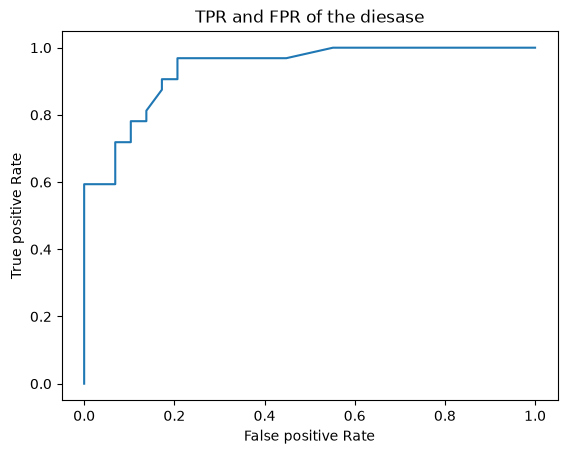

In [22]:
fig , ax = plt.subplots()
ax.plot(fpr,tpr)
ax.set(title="TPR and FPR of the diesase", xlabel="False positive Rate",ylabel="True positive Rate")

In [26]:
# confusion matrix
from sklearn.metrics import confusion_matrix
y_probs = clf.predict(x_test)
cf = confusion_matrix(y_test,y_probs)
cf

array([[24,  5],
       [ 4, 28]])

<Axes: >

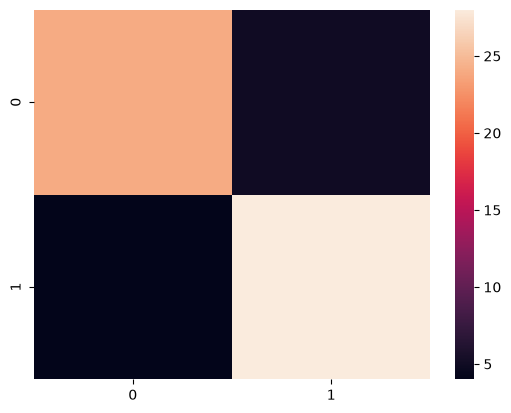

In [27]:
import seaborn as sns
sns.heatmap(cf)

In [10]:
from sklearn.model_selection import cross_val_score
cross_val_score(clf,x,y,cv=5, scoring="accuracy")

array([0.81967213, 0.86885246, 0.7704918 , 0.78333333, 0.8       ])

In [11]:
np.mean(cross_val_score(clf,x,y,cv=5, scoring="accuracy"))

np.float64(0.8248633879781421)